In [2]:
import xarray as xr 
import torch 
import matplotlib.pyplot as plt
import numpy as np
import cartopy 

In [3]:
IG = np.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-02-15/tensor_steps24_parrallel_lev00020_lat00149_lon00096.npy')

In [11]:
IG_s = IG.squeeze()

# Largest absolute gradient anywhere in each level
level_abs_max = np.nanmax(np.abs(IG_s), axis=(1, 2))

# Top 5 levels, sorted from largest to smaller
top5_levels = np.argsort(level_abs_max)[-5:][::-1]

for rank, lev in enumerate(top5_levels, start=1):
    ilat, ilon = np.unravel_index(
        np.nanargmax(np.abs(IG_s[lev, :, :])),
        IG_s[lev, :, :].shape,
    )

    signed_value = IG_s[lev, ilat, ilon]
    abs_value = np.abs(signed_value)

    print(f"Rank {rank}")
    print("Level:", lev)
    print("Signed value:", signed_value)
    print("Absolute value:", abs_value)
    print("Lat index:", ilat)
    print("Lon index:", ilon)
    print()

Rank 1
Level: 128
Signed value: -337.36548
Absolute value: 337.36548
Lat index: 121
Lon index: 143

Rank 2
Level: 82
Signed value: 1.844689
Absolute value: 1.844689
Lat index: 122
Lon index: 146

Rank 3
Level: 83
Signed value: 1.6189629
Absolute value: 1.6189629
Lat index: 122
Lon index: 146

Rank 4
Level: 86
Signed value: -1.5323144
Absolute value: 1.5323144
Lat index: 122
Lon index: 145

Rank 5
Level: 85
Signed value: -1.5271529
Absolute value: 1.5271529
Lat index: 122
Lon index: 146



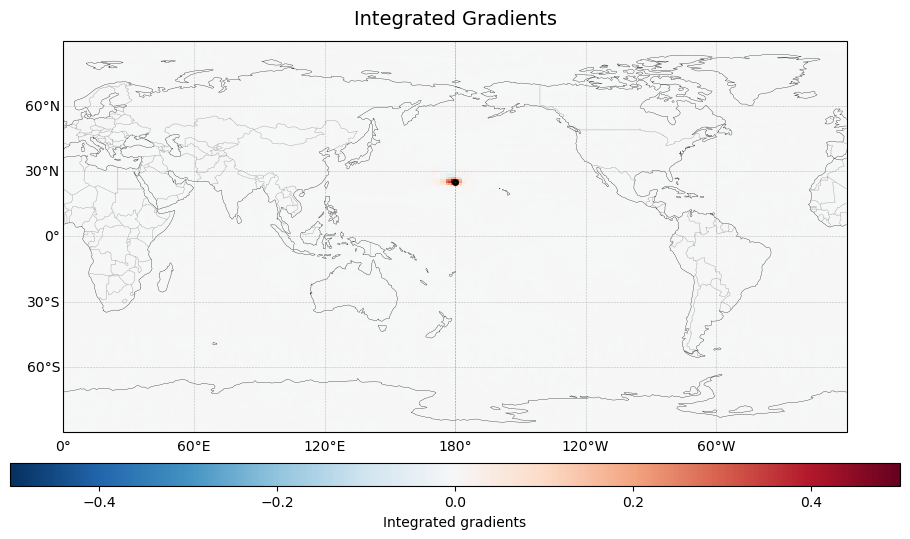

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-02-15/"

IG = np.load(dir_o + "tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy").squeeze()
field_show = IG[20, :, :].squeeze()

DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
lat = DS["lat"].values if hasattr(DS["lat"], "values") else DS["lat"]
lon = DS["lon"].values if hasattr(DS["lon"], "values") else DS["lon"]

field_cyc, lon_cyc = add_cyclic_point(field_show, coord=lon)

vmax = np.nanmax(np.abs(field_cyc))
vmin = -vmax

fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

im = ax.pcolormesh(
    lon_cyc,
    lat,
    field_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = 122
lon_idx = 144

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

ax.plot(
    dot_lon,
    dot_lat,
    marker="o",
    markersize=3,
    markerfacecolor="none",
    markeredgecolor="black",
    markeredgewidth=2,
    transform=ccrs.PlateCarree(),
    zorder=10,
)

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

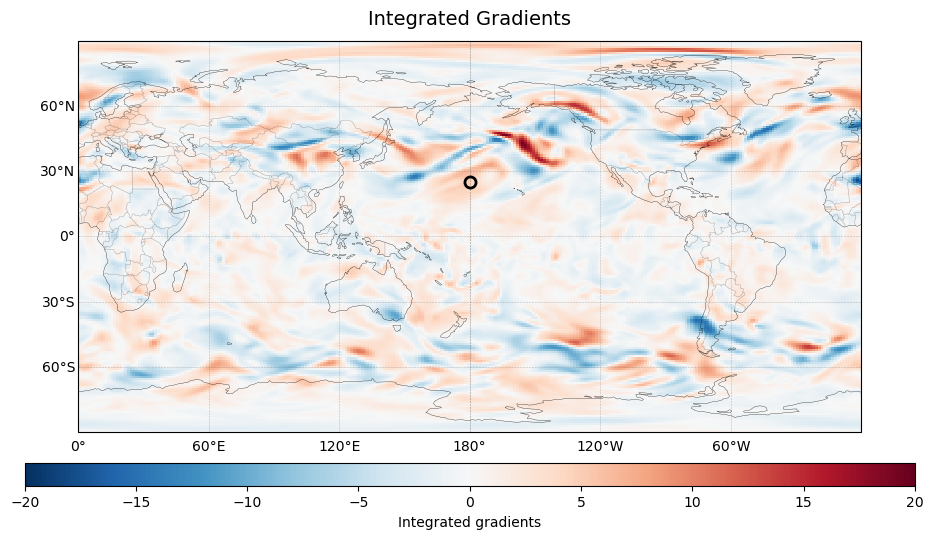

In [31]:
t1 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-02-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t2 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-02-15_06_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-20; vmax=20
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t2[20,:,:]-t1[20,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = 122
lon_idx = 144

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

ax.plot(
    dot_lon,
    dot_lat,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgecolor="black",
    markeredgewidth=2,
    transform=ccrs.PlateCarree(),
    zorder=10,
)

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [51]:
# input concatenated tensor's indexes for each input variable

# U = input_tensor[0:32]
# V = input_tensor[32:64]
# T = input_tensor[64:96]
# Q = input_tensor[96:128]

# TREFHT = input_tensor[129]
# PS = input_tensor[128]

# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

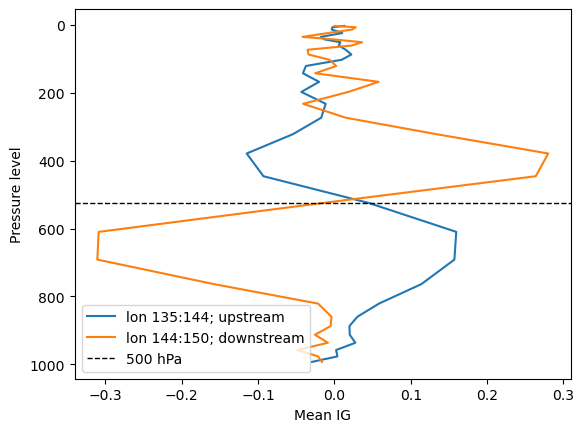

In [127]:
plt.plot(
    np.mean(np.mean(IG[64:96, 142:156, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream")

plt.plot(
    np.mean(np.mean(IG[64:96, 142:156, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream")

plt.axhline(
    y=524.6871747076511,
    color="k",
    linestyle="--",
    linewidth=1,
    label="500 hPa",
)

plt.gca().invert_yaxis()
plt.xlabel("Mean IG")
plt.ylabel("Pressure level")
plt.legend()

plt.show()